###  Flagging vendor invoice for manual review 

**objective:** predict whether a vendor invoice should be flagged for manual approved based on abnormal cost, or delivery  patterns, in order to reduce financial risk,improve operational efficiency,and priortize human review where it adds the most value .

* manual invoice review is time-consuming and does not scale with transaction volume.

* abmormal freight charges,pricing deviation,or delivery delays often indicate errors,disputes,or compliance risks.

* an automated flagging system enables teams to focus attention on high-risk invoice  while allowing low-risk invoice to be processed automatically.

In [1]:
import sqlite3 

import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
conn=sqlite3.connect("/Users/mac/Documents/invoice Intelligent project/data/inventory.db")
tables= pd.read_sql_query("select name from sqlite_master where type ='table'",conn)

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
    print('table name',table)
    df=pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
purchase_agg_df=pd.read_sql_query("""
select 
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""",conn)

In [6]:
purchase_agg_df.shape

(5543, 5)

In [7]:
pd.read_sql_query("""
select 
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate)-julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate)-julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi

""",conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [8]:
df=pd.read_sql_query("""
WITH purchase_agg AS(
    select 
        p.PONumber,
        count(distinct p.Brand) as total_brands,
        sum(p.Quantity) as total_item_quantity,
        sum(p.Dollars) as total_item_dollars,
        avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_receiving_delay
        from purchases p
        group by p.PONumber
)
select 
    vi.PONumber,
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate)-julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate)-julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.avg_receiving_delay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars
from vendor_invoice vi
left join purchase_agg pa 
ON vi.PONumber=pa.PONumber
""",conn)

In [9]:
df.isna().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
avg_receiving_delay    0
total_brands           0
total_item_quantity    0
total_item_dollars     0
dtype: int64

In [10]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
avg_receiving_delay    float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
dtype: object

In [11]:
def create_invoice_risk_label(row):
    ## Invoice  total mismatch wdf[ith item-level total 
    if(abs(row['invoice_dollars']-row['total_item_dollars'])>5):
        return 1

    
    ## Abnormally high receiving delay 
    if row["avg_receiving_delay"]>10:
        return 1 
    
    return 0

df['flag_invoice']=df.apply(create_invoice_risk_label,axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

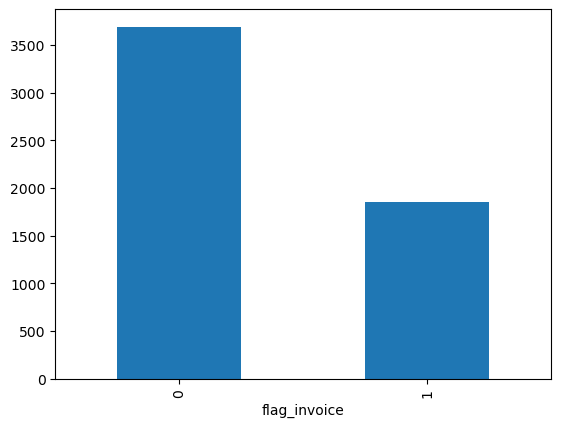

In [12]:
df['flag_invoice'].value_counts().plot(kind='bar')

In [13]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,avg_receiving_delay,total_brands,total_item_quantity,total_item_dollars,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,-0.042362,0.013423,0.049442,0.059221,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.000519,0.566394,0.706117,0.668171,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.004694,0.536952,0.667666,0.679537,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.015645,0.536381,0.656616,0.670768,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.515538,0.009519,0.005543,0.007931,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,-0.029403,0.020336,0.016203,0.015610,-0.005289
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,1.000000,0.000496,-0.014016,-0.014251,0.311667
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,0.000496,1.000000,0.783825,0.753092,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,-0.014016,0.783825,1.000000,0.963831,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,-0.014251,0.753092,0.963831,1.000000,0.037994


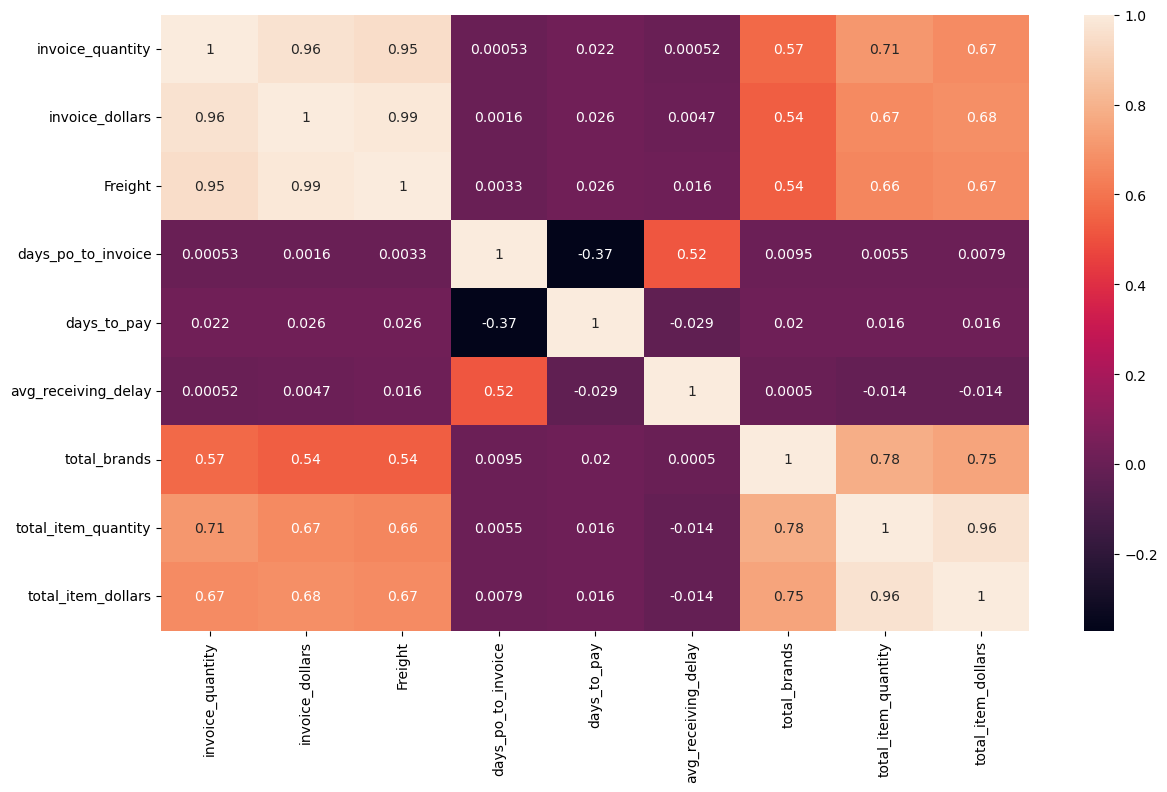

In [14]:
plt.figure(figsize=(14,8))
sns.heatmap(df.iloc[:,1:-1].corr(),annot=True)
plt.show()

In [15]:
flagged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

In [16]:
flagged

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,avg_receiving_delay,total_brands,total_item_quantity,total_item_dollars,flag_invoice
0,8124,6,214.26,3.47,14.0,43.0,12.000000,1,6,214.26,1
1,8137,15,140.55,8.57,16.0,45.0,10.333333,2,15,140.55,1
3,8106,10100,137483.78,2935.20,23.0,24.0,12.614130,81,10100,137483.78,1
10,8107,24,348.72,9.08,16.0,36.0,12.500000,2,24,348.72,1
12,8125,12,105.36,0.50,18.0,30.0,11.000000,1,12,105.36,1
...,...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,5.871795,2,223,6823.18,1
5539,13661,4617,37300.48,186.50,18.0,39.0,5.050500,110,24747,149007.56,1
5540,13643,9848,202815.78,932.95,11.0,33.0,5.000000,5,180,2559.72,1
5541,13602,24747,149007.56,819.54,14.0,36.0,8.045541,83,43240,318075.65,1


In [17]:
normal


,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,avg_receiving_delay,total_brands,total_item_quantity,total_item_dollars,flag_invoice
2,8169,5,106.60,4.61,16.0,38.0,9.000000,1,5,106.60,0
4,8170,1935,15527.25,429.20,14.0,36.0,8.752809,29,1935,15527.25,0
5,8191,23,234.83,2.30,14.0,29.0,8.000000,1,23,234.83,0
6,8150,4684,65403.57,1808.77,17.0,41.0,9.619835,53,4684,65403.57,0
7,8171,6,132.30,5.29,16.0,26.0,8.000000,1,6,132.30,0
...,...,...,...,...,...,...,...,...,...,...,...
5121,13237,36,767.52,3.99,20.0,36.0,8.666667,1,36,767.52,0
5256,13421,57118,472589.43,2410.21,19.0,35.0,6.111394,231,57118,472589.43,0
5295,13405,4913,36352.10,167.22,13.0,36.0,7.127854,10,4913,36352.10,0
5307,13442,242,1066.79,5.33,15.0,27.0,4.736842,2,242,1066.79,0


In [18]:
significant_features=[]
non_significant_features=[]
results=[]

In [19]:
metrics=['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice','days_to_pay','total_brands','total_item_quantity','total_item_dollars','avg_receiving_delay']

In [20]:
from scipy.stats import ttest_ind


for metric in metrics:
    flagged_mean=flagged[metric].mean()
    normal_mean=normal[metric].mean()


    t_stat,p_value=ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value<0.05:
        significant_features.append(metric)
        results.append({
            'metric':metric,
            'flagged_mean':flagged_mean.round(2),
            'normal_mean':normal_mean.round(2),
            'p_value':p_value.round(3)
    })

    else:
        non_significant_features.append(metric)

In [21]:
non_significant_features

['days_to_pay', 'total_brands']

In [22]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [23]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [ ]:
X=df[['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice','total_item_quantity','total_item_dollars','avg_receiving_delay']]
y=df['flag_invoice']

In [25]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [26]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [27]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (using stratification since it's a classification task)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit scaler on training data and transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier


In [ ]:
model1=LogisticRegression(random_state=42)
model1.fit(X_train_scaled,y_train)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(model, X_test, y_test, model_name: str):
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    print(f"=== {model_name} Performance ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, preds, zero_division=0))
    print("-" * 50 + "\n")

evaluate_model(model1, X_test_scaled, y_test, 'LogisticRegression')
evaluate_model(model2, X_test_scaled, y_test, 'DecisionTree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')

=== LogisticRegression Performance ===
Accuracy : 0.7556
Precision: 0.7391
Recall   : 0.4135
F1-Score : 0.5303

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.93      0.83       739
           1       0.74      0.41      0.53       370

    accuracy                           0.76      1109
   macro avg       0.75      0.67      0.68      1109
weighted avg       0.75      0.76      0.73      1109

--------------------------------------------------

=== DecisionTree Classifier Performance ===
Accuracy : 0.9549
Precision: 0.9444
Recall   : 0.9189
F1-Score : 0.9315

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       739
           1       0.94      0.92      0.93       370

    accuracy                           0.95      1109
   macro avg       0.95      0.95      0.95      1109
weighted avg       0.95      0.95      0.95      1109

-------------------

In [31]:
model3.feature_importances_

array([0.11902435, 0.11533858, 0.08599742, 0.02687188, 0.16300068,
       0.19911937, 0.29064772])

In [32]:
feature_importance=pd.DataFrame({
    "Feature":X_train.columns,
    "importance":model3.feature_importances_
}).sort_values(by="importance",ascending=False)

feature_importance

,Feature,importance
6,avg_receiving_delay,0.290648
5,total_item_dollars,0.199119
4,total_item_quantity,0.163001
0,invoice_quantity,0.119024
1,invoice_dollars,0.115339
2,Freight,0.085997
3,days_po_to_invoice,0.026872


In [33]:
X=df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars']]
y=df['flag_invoice']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')

=== Random Forest Classifier Performance ===
Accuracy : 0.8792
Precision: 0.9436
Recall   : 0.6784
F1-Score : 0.7893

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       739
           1       0.94      0.68      0.79       370

    accuracy                           0.88      1109
   macro avg       0.90      0.83      0.85      1109
weighted avg       0.89      0.88      0.87      1109

--------------------------------------------------



In [39]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Corrected parameter names: min_samples_split and min_samples_leaf (with an 's')
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 4, 6],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "criterion": ['gini', 'entropy']
}

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search.best_estimator_, X_test_scaled, y_test, 'Optimized Random Forest Classifier')

Fitting 5 folds for each of 48 candidates, totalling 240 fits
=== Optimized Random Forest Classifier Performance ===
Accuracy : 0.8846
Precision: 0.9549
Recall   : 0.6865
F1-Score : 0.7987

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       739
           1       0.95      0.69      0.80       370

    accuracy                           0.88      1109
   macro avg       0.91      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109

--------------------------------------------------



In [40]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [42]:
confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[727, 116],
       [ 12, 254]])

In [43]:
confusion_matrix(model3.predict(X_test_scaled),y_test)

array([[724, 119],
       [ 15, 251]])

In [45]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}